<a href="https://colab.research.google.com/github/shahzad-jatoi/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shahzad-jatoi/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/shahzad-jatoi/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    os.chdir("/content")
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(f"/content/{REPO_DIR}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import duckdb, pandas as pd, numpy as np, json, os

if IN_COLAB:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
else:
    hf_token = os.environ.get("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
DIM_CONTENT = f"{WAREHOUSE}/dim_content.parquet"
FACT_MONTH = f"{WAREHOUSE}/fact_content_daily_performance/month=2026-03/data_0.parquet"
print("Setup done.")

Setup done.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

scored = con.sql(f"""
    WITH agg AS (
        SELECT content_hash_id,
               AVG(gsc_impressions) as avg_impressions,
               AVG(gsc_clicks * 1.0 / NULLIF(gsc_impressions,0)) as avg_ctr,
               AVG(gsc_avg_position) as avg_position
        FROM read_parquet('{FACT_MONTH}')
        WHERE gsc_data_available IS TRUE
        GROUP BY content_hash_id
    )
    SELECT a.content_hash_id,
           DATE_DIFF('day', c.content_updated_date, DATE '2026-03-31') as days_since_update,
           c.word_count,
           a.avg_impressions, a.avg_ctr, a.avg_position,
           (a.avg_impressions *
            (DATE_DIFF('day', c.content_updated_date, DATE '2026-03-31')/365.0) /
            (a.avg_ctr + 0.005)) as score,
           CASE
               WHEN a.avg_position <= 10 AND a.avg_ctr < 0.005 THEN 'PAGE1_LOW_CTR'
               WHEN DATE_DIFF('day', c.content_updated_date, DATE '2026-03-31') >= 270 THEN 'STALE_DECAY_ZONE'
               WHEN c.word_count < 1500 AND a.avg_impressions >= 50 THEN 'THIN_BUT_VISIBLE'
               ELSE 'STALE_LOW_CTR'
           END as reason_code,
           'refresh_priority' as action
    FROM agg a
    JOIN read_parquet('{DIM_CONTENT}') c ON a.content_hash_id = c.content_hash_id
    WHERE DATE_DIFF('day', c.content_updated_date, DATE '2026-03-31') >= 90
      AND a.avg_impressions >= 20
      AND c.is_deleted IS NOT TRUE
    ORDER BY score DESC
""").df()

print(f"Ranked queue: {len(scored)} rows")
print(scored['reason_code'].value_counts())
scored.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ranked queue: 59 rows
reason_code
STALE_LOW_CTR    47
PAGE1_LOW_CTR    12
Name: count, dtype: int64


,content_hash_id,days_since_update,word_count,avg_impressions,avg_ctr,avg_position,score,reason_code,action
0,content_097459d155cccb26,124,2591,1223.548387,0.001265,17.550666,66348.518893,STALE_LOW_CTR,refresh_priority
1,content_ac4e2d9d3bbb06de,124,4087,1075.741935,0.000819,23.327797,62800.911611,STALE_LOW_CTR,refresh_priority
2,content_66d1fffc91f4f029,124,5125,1001.225806,0.001689,15.216861,50849.440050,STALE_LOW_CTR,refresh_priority
3,content_f2df5a8a9057783e,124,3587,1160.645161,0.003050,15.542928,48979.804154,STALE_LOW_CTR,refresh_priority
4,content_b956947c822af734,124,4860,725.870968,0.000295,36.484478,46571.078673,STALE_LOW_CTR,refresh_priority
5,content_9598a57544925111,123,3966,776.322581,0.001221,12.873404,42050.053293,STALE_LOW_CTR,refresh_priority
6,content_47da45b084a73115,124,4134,476.580645,0.000179,50.756106,31260.907238,STALE_LOW_CTR,refresh_priority
7,content_b361694d518f80e2,124,3987,583.967742,0.002472,16.775321,26551.771150,STALE_LOW_CTR,refresh_priority
8,content_0d2aaf57d7146812,123,3545,679.354839,0.003747,9.765313,26174.074706,PAGE1_LOW_CTR,refresh_priority
9,content_dfbc1b6a0f68e28c,124,3861,512.225806,0.002491,23.107159,23228.956371,STALE_LOW_CTR,refresh_priority


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content lead or SEO strategist uses this ranked queue to prioritize which existing pages get editorial refresh attention this cycle nothing else. It is a triage aid, not a publishing decision-maker.

**What this is NOT:** this is not a predictive model output. The Week 5-6 predictive model (logistic regression forecasting future decline) failed honest time-aware validation its accuracy dropped from 0.669 (naive split) to 0.274 (honest split), below a majority-class guess. That model is not included in this playbook and should not be treated as production-ready. What IS included here is the Week 4 baseline rule: an interpretable, hand-written score combining staleness, impressions, and CTR, re-validated with the honest signal checks from ML-07 (CTR-vs-position: CONFIRMED; staleness-vs-position: MIXED).

**Limits:**
- Built on one month's snapshot (2026-03) not re-validated across multiple months
- The staleness signal was only MIXED, not CONFIRMED, so `STALE_LOW_CTR`-flagged pages carry more uncertainty than `PAGE1_LOW_CTR` ones
- Anonymized, hash-keyed data only no way to inspect what a page is actually about, so a human must open the real page before acting
- Correlational, not causal a high score means "this page's pattern resembles pages that historically had room to improve," not "refreshing this page will work"

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any flagged page, a human must check:**
- Open the actual page confirm it's still relevant to current business priorities, not a page slated for removal
- Confirm the page isn't already mid-refresh or scheduled for one (avoid duplicate effort)
- Sanity-check that recent low performance isn't explained by a known one-off cause (algorithm update, seasonal dip, a broken page element) rather than genuine staleness
- Verify the page doesn't belong to a client with known data gaps (per the Week 3 data-limits finding some clients have thin GSC/GA4 coverage, which can distort the score)

**No-go list — must never be automated:**
- Auto-publishing any refreshed content without human editorial review
- Auto-deleting or de-indexing pages flagged as low-value, even repeatedly
- Using this queue to make client-facing promises about expected traffic lift (the paper itself avoids revenue claims for the same reason attribution isn't clean enough)
- Feeding the failed predictive model's output into this queue or any client-facing report
- Treating the ranked order as a guarantee of return on effort it's a priority hint, not a forecast

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# A lightweight monitoring check: re-verify the two Week 4 signal checks still hold
# on a more recent month, as a staleness detector for the playbook itself

sig_check = con.sql(f"""
    SELECT
        CASE WHEN gsc_avg_position <= 10 THEN 'top10' ELSE 'below10' END as tier,
        AVG(gsc_clicks * 1.0 / NULLIF(gsc_impressions,0)) as avg_ctr,
        COUNT(*) as n
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month=2026-05/data_0.parquet')
    WHERE gsc_data_available IS TRUE AND gsc_impressions > 0
    GROUP BY 1
""").df()
print(sig_check)
print("\nIf CTR no longer drops meaningfully from top10 to below10 in a newer month,")
print("the core signal this playbook relies on may have shifted -- treat as a retrain trigger.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      tier   avg_ctr        n
0    top10  0.004999  1935904
1  below10  0.002094  2437518

If CTR no longer drops meaningfully from top10 to below10 in a newer month,
the core signal this playbook relies on may have shifted -- treat as a retrain trigger.


**Retrain / re-check triggers:**
- The CTR-vs-position gap (checked above on a later month) narrows or disappears the core signal the rule leans on has weakened
- A new month's ranked queue barely overlaps with this one (e.g. <30% of top-20 pages repeat) suggests the score is unstable, not just refreshing priorities
- Any client is added with substantially different GSC/GA4 coverage patterns than this sample
- More than ~90 days pass since this queue was generated content and search landscape both drift
- If the predictive model (Week 5-6) is ever revisited and retrained, it must pass the same honest time-aware validation from ML-09 before it's allowed to replace or supplement this rule-based queue

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue (stays OUT of git per CI leak-guard)
scored.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(scored)} rows to work/outputs/action_playbook_queue.csv")

# Export metrics receipt (THIS gets committed)
metrics = {
    "n_ranked": len(scored),
    "reason_code_counts": scored["reason_code"].value_counts().to_dict(),
    "month_used": "2026-03",
    "signal1_staleness_verdict": "MIXED",
    "signal2_ctr_position_verdict": "CONFIRMED",
    "predictive_model_status": "FAILED_HONEST_VALIDATION",
    "predictive_model_note": "Accuracy dropped 0.669 -> 0.274 under time-aware split; excluded from this playbook",
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics:", metrics)

Wrote 59 rows to work/outputs/action_playbook_queue.csv
Saved metrics: {'n_ranked': 59, 'reason_code_counts': {'STALE_LOW_CTR': 47, 'PAGE1_LOW_CTR': 12}, 'month_used': '2026-03', 'signal1_staleness_verdict': 'MIXED', 'signal2_ctr_position_verdict': 'CONFIRMED', 'predictive_model_status': 'FAILED_HONEST_VALIDATION', 'predictive_model_note': 'Accuracy dropped 0.669 -> 0.274 under time-aware split; excluded from this playbook'}


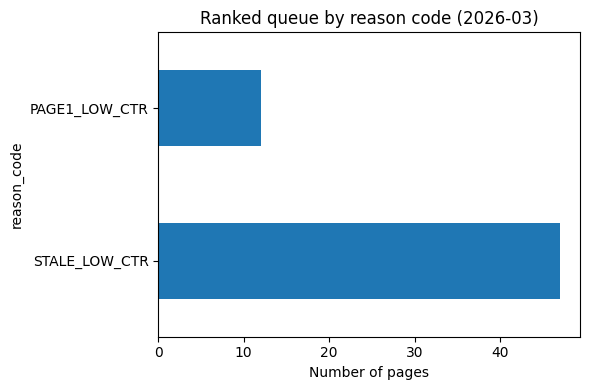

Saved figure to work/figures/w07_reason_code_breakdown.png


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
scored["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of pages")
ax.set_title("Ranked queue by reason code (2026-03)")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_breakdown.png", dpi=150)
plt.show()
print("Saved figure to work/figures/w07_reason_code_breakdown.png")

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.